In [1]:
import os
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, Activation, Flatten, BatchNormalization, Conv2D, MaxPooling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)

import matplotlib.pyplot as plt

## 1. Основні налаштування

In [3]:
num_classes = 7
img_rows, img_cols = 48, 48
batch_size = 32

train_data_dir = r'train'
validation_data_dir = r'test'


nb_train_samples = 28709
nb_validation_samples = 7178
epochs = 25

## 2. Генератори даних

In [4]:
# Аугментація для train
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    shear_range=0.3,
    zoom_range=0.3,
    width_shift_range=0.4,
    height_shift_range=0.4,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Для validation під час навчання — тільки нормалізація
validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    color_mode='grayscale',
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    color_mode='grayscale',
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

# ОКРЕМА генерація для оцінки якості (ВАЖЛИВО: shuffle=False)
eval_datagen = ImageDataGenerator(rescale=1./255)

eval_generator = eval_datagen.flow_from_directory(
    validation_data_dir,
    color_mode='grayscale',
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


## 3. Модель CNN типу Little VGG

In [5]:
model = Sequential()

# Block-1
model.add(Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal',
                 input_shape=(img_rows, img_cols, 1)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# Block-2
model.add(Conv2D(64, (3,3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# Block-3
model.add(Conv2D(128, (3,3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# Block-4
model.add(Conv2D(256, (3,3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3,3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# Block-5 (Dense)
model.add(Flatten())
model.add(Dense(64, kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Block-6 (Dense)
model.add(Dense(64, kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Block-7 (Output)
model.add(Dense(num_classes, kernel_initializer='he_normal'))
model.add(Activation('softmax'))

print(model.summary())

D:\ProgramFiles\Python3.10\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 48, 48, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 48, 48, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │              

 Total params: 1,328,167 (5.07 MB)

 Trainable params: 1,325,991 (5.06 MB)

 Non-trainable params: 2,176 (8.50 KB)

None


## 4. Callbacks

In [6]:
checkpoint = ModelCheckpoint(
    'Emotion_little_vgg.h5',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=3,
    verbose=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_delta=1e-4
)

callbacks = [earlystop, checkpoint, reduce_lr]

## 5. Навчання

In [7]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    steps_per_epoch=nb_train_samples // batch_size,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=validation_generator,
    validation_steps=nb_validation_samples // batch_size
)

Epoch 1/25


D:\ProgramFiles\Python3.10\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.1830 - loss: 2.4481
Epoch 1: val_loss improved from inf to 1.78208, saving model to Emotion_little_vgg.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 170s 182ms/step - accuracy: 0.1830 - loss: 2.4477 - val_accuracy: 0.2656 - val_loss: 1.7821 - learning_rate: 0.0010
Epoch 2/25
  1/897 ━━━━━━━━━━━━━━━━━━━━ 2:19 155ms/step - accuracy: 0.3125 - loss: 1.7650

D:\ProgramFiles\Python3.10\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


...

897/897 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.4375 - loss: 1.6516 - val_accuracy: 0.2995 - val_loss: 1.7333 - learning_rate: 0.0010
Epoch 9/25
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.2864 - loss: 1.7351
Epoch 9: val_loss improved from 1.73326 to 1.60329, saving model to Emotion_little_vgg.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 145s 162ms/step - accuracy: 0.2864 - loss: 1.7351 - val_accuracy: 0.3378 - val_loss: 1.6033 - learning_rate: 0.0010
Epoch 10/25
  1/897 ━━━━━━━━━━━━━━━━━━━━ 2:11 147ms/step - accuracy: 0.3438 - loss: 1.5970
Epoch 10: val_loss improved from 1.60329 to 1.60106, saving model to Emotion_little_vgg.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.3438 - loss: 1.5970 - val_accuracy: 0.3403 - val_loss: 1.6011 - learning_rate: 0.0010
Epoch 11/25
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.3203 - loss: 1.6778
Epoch 11: val_loss improved from 1.60106 to 1.44331, saving model to Emotion_little_vgg.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 145s 162ms/step - accuracy: 0.3203 - loss: 1.6778 - val_accuracy: 0.4494 - val_loss: 1.4433 - learning_rate: 0.0010
Epoch 12/25
  1/897 ━━━━━━━━━━━━━━━━━━━━ 2:35 174ms/step - accuracy: 0.3125 - loss: 1.6151
Epoch 12: val_loss did not improve from 1.44331
897/897 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.3125 - loss: 1.6151 - val_accuracy: 0.4492 - val_loss: 1.4458 - learning_rate: 0.0010
Epoch 13/25
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.3773 - loss: 1.5912
Epoch 13: val_loss improved from 1.44331 to 1.33452, saving model to Emotion_little_vgg.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 145s 162ms/step - accuracy: 0.3773 - loss: 1.5912 - val_accuracy: 0.4874 - val_loss: 1.3345 - learning_rate: 0.0010
Epoch 14/25
  1/897 ━━━━━━━━━━━━━━━━━━━━ 2:25 163ms/step - accuracy: 0.4375 - loss: 1.3531
Epoch 14: val_loss did not improve from 1.33452
897/897 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.4375 - loss: 1.3531 - val_accuracy: 0.4880 - val_loss: 1.3379 - learning_rate: 0.0010
Epoch 15/25
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.4053 - loss: 1.5196
Epoch 15: val_loss did not improve from 1.33452
897/897 ━━━━━━━━━━━━━━━━━━━━ 141s 157ms/step - accuracy: 0.4053 - loss: 1.5196 - val_accuracy: 0.4738 - val_loss: 1.3515 - learning_rate: 0.0010
Epoch 16/25
  1/897 ━━━━━━━━━━━━━━━━━━━━ 2:11 147ms/step - accuracy: 0.4688 - loss: 1.6083
Epoch 16: val_loss did not improve from 1.33452

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
897/897 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.4688 - loss: 1.6083 

## 6. Learning loss / accuracy

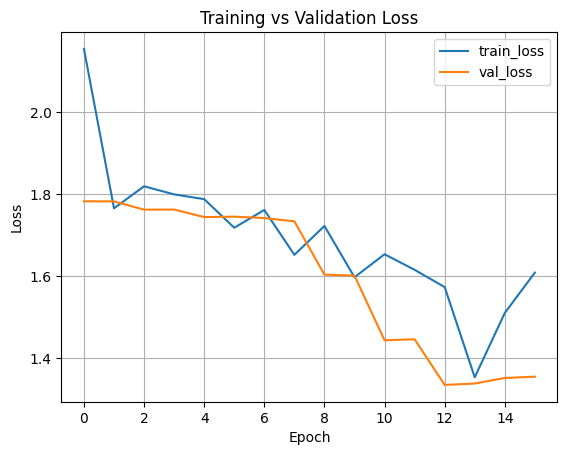

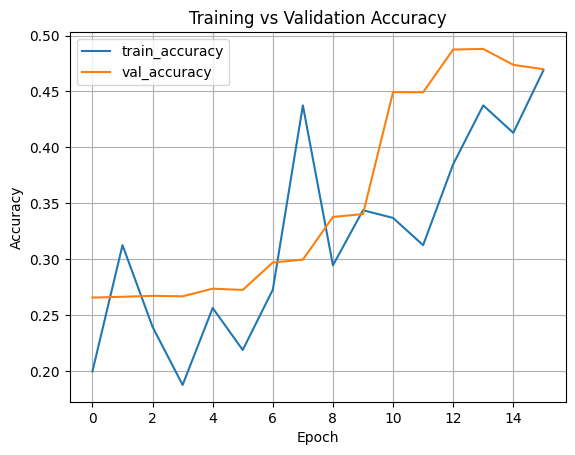

In [8]:
# Loss
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 7. Оцінка моделі на validation set
###    (accuracy, confusion matrix, precision/recall/F1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step
Validation accuracy: 0.4871830593480078
Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Confusion matrix:
 [[ 194    0   32   85  149  444   54]
 [  31    0    2   14   11   50    3]
 [ 168    0   52   64  214  368  158]
 [  69    0   29 1327  131  176   42]
 [  46    0    9   65  652  450   11]
 [ 133    0   19   77  266  738   14]
 [  50    0   40   51  119   37  534]]


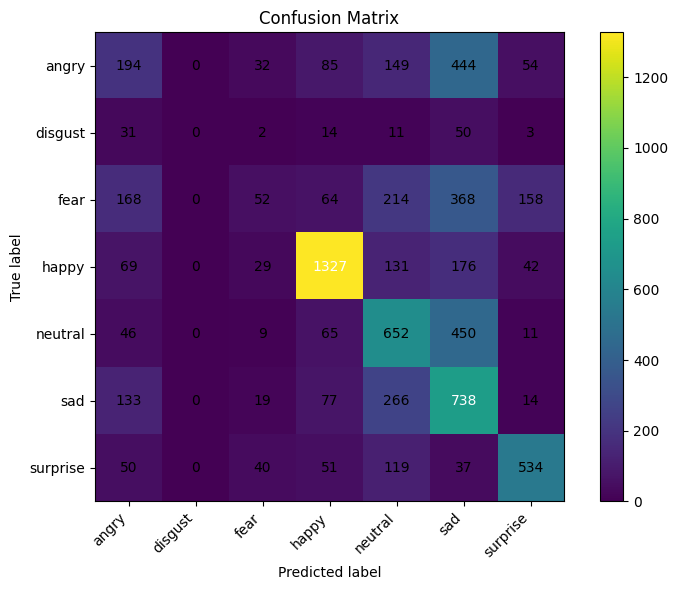

Classification report:
               precision    recall  f1-score   support

       angry     0.2808    0.2025    0.2353       958
     disgust     0.0000    0.0000    0.0000       111
        fear     0.2842    0.0508    0.0862      1024
       happy     0.7885    0.7480    0.7677      1774
     neutral     0.4228    0.5288    0.4699      1233
         sad     0.3261    0.5918    0.4205      1247
    surprise     0.6544    0.6426    0.6485       831

    accuracy                         0.4872      7178
   macro avg     0.3938    0.3949    0.3754      7178
weighted avg     0.4779    0.4872    0.4623      7178



D:\ProgramFiles\Python3.10\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\ProgramFiles\Python3.10\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\ProgramFiles\Python3.10\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
# Прогнози й істинні мітки
y_prob = model.predict(eval_generator)
y_pred = np.argmax(y_prob, axis=1)
y_true = eval_generator.classes

# Accuracy
val_accuracy = accuracy_score(y_true, y_pred)
print("Validation accuracy:", val_accuracy)

# Назви класів (у правильному порядку)
class_indices = eval_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print("Class names:", class_names)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)

# Візуалізація confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest')
ax.set_title('Confusion Matrix')
plt.colorbar(im)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.show()

# Classification report (precision / recall / F1)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification report:\n", report)